<h1 align="center">📚 Build Your Own Research Assistant</h1>

## Introduction

When I was working on my master’s thesis, I remember how overwhelming it felt to sift through research papers. There were so many articles, and figuring out which ones were actually relevant took a huge amount of time and energy. A couple of years later, the situation has only intensified, with thousands of new papers being published every single day. 

For researchers (especially in fast-moving fields), keeping up with the latest developments has become nearly impossible. Whether you're just getting started or you're a seasoned academic, manually digging through endless abstracts and full PDFs is exhausting, inefficient, and often discouraging.
That’s why I wanted to build a personal research assistant - an AI-powered tool that can search, filter, read, and discuss papers with you, making the process of finding relevant information in this vast sea of papers less painful.

This project is part of Kaggle and Google’s Gen AI Intensive course. It’s not meant to be a fully production-ready solution, but rather a practical demonstration of techniques you can use to build your own intelligent tools for navigating research more effectively. Parts of code were reused, mainly parts from day-2 and day-3 notebooks that can be found [on the Kaggle learn guide](https://www.kaggle.com/learn-guide/5-day-genai?utm_medium=email&utm_source=gamma&utm_campaign=learn-5daygenai). In this project we will **not** discuss topics like what RAG is or how it works, but provide an example of how it can help us study and improve our productivity. For more theory about embeddings, RAG and LLM agents, refer to the previously mentioned link!

## Project idea

In this project, we will use one of Kaggle's most awarded datasets: the [arXiv dataset](https://www.kaggle.com/datasets/Cornell-University/arxiv). It provides titles, abstracts and metadata for all the articles on [arXiv](https://arxiv.org/) and is updated frequently!


Our goal is to build a RAG (Retrieval-Augmented Generation) system that is able to understand and have a Q&A about research papers. While a typical approach might involve downloading full PDFs, embedding their contents, and running Q&A directly on them, this can be costly. Embedding large texts requires significant computational resources, not to mention the expense of dealing with long token sequences.


To make things more efficient and scalable, we'll take a smarter, agentic approach. Instead of embedding entire PDFs up front, we’ll start by indexing only the titles and abstracts from the arXiv dataset. When the user expresses interest in a specific paper, the assistant will dynamically download and embed that PDF on demand - right when it’s needed for Q&A. 

This setup effectively creates two RAG systems:
1. **Abstract-level RAG:** For searching and suggesting relevant papers.
2. **PDF-level RAG:** For in-depth discussion once the user selects a specific paper.

### Example Conversation Flow

- <span style="color:red">**Agent:**</span> Hi, how can I help you?
- <span style="color:green">**User:**</span> I want to learn about topic X.
- *Agent searches arXiv abstracts using RAG.*
- <span style="color:red">**Agent:**</span> Here are the top papers I found related to topic X.
- <span style="color:green">**User:**</span> I’d like to dive into article Y.
- *Agent downloads and embeds article Y’s full PDF.*
- <span style="color:red">**Agent:**</span> Article Y is ready. Let’s talk about it!
- *User and agent have a detailed conversation about the paper.*
- <span style="color:green">**User:**</span> I’m done with that one.
- *Agent removes article Y from the database to free up memory and potenitally prepare for the next topic. User can then choose another paper or topic.*
- <span style="color:green">**User:**</span> quit

---

Now that the main idea is set and we are happy with it, let's dive into the code!

> **Environment Compatibility Note**

This notebook uses a set of packages that may conflict with each other or not work properly with the **latest Kaggle Docker image** (e.g., due to version mismatches or deprecated dependencies). However, if you **copy this notebook**, Kaggle also copies the **original environment** it was run on - so everything should work out of the box.

Just avoid updating the base image or packages unless you're ready to debug conflicts!


In [1]:
!pip uninstall -qqy \
    kfp jupyterlab libpysal thinc spacy fastai ydata-profiling google-cloud-bigquery google-generativeai   # Remove unused conflicting packages

In [2]:
!pip install -qU \
    "langgraph==0.3.21" \
    "langchain-google-genai==2.1.2" \
    "langgraph-prebuilt==0.1.7" \
    "google-genai==1.7.0" \
    "chromadb==0.6.3" \
    "langchain-community==0.3.21"

## Before running!

Make sure that both the [arXiv](https://www.kaggle.com/datasets/Cornell-University/arxiv) and our [test dataset](https://www.kaggle.com/datasets/rokoroks/metadata-for-genai-course-project-notebook) are loaded as input to the notebook:

> **Let's import everything we need**

We'll start by importing all the necessary libraries:

- `chromadb` for handling vector embeddings and retrieval.
- `google.genai` to access Google’s embedding and chat models.
- `langchain` and `langgraph` to build our AI agent and structure its behavior.
- Standard Python libraries for data handling, display, and type annotations.


In [3]:
# Standard library imports
import json
import numpy as np
import os
import pandas as pd
import requests
import time

from dataclasses import dataclass
from kaggle_secrets import UserSecretsClient
from pprint import pprint
from typing import Annotated, Dict, List, Literal
from typing_extensions import TypedDict
from IPython.display import Image, Markdown, display

# ChromaDB imports
import chromadb
from chromadb import Documents, EmbeddingFunction, Embeddings

# Google imports
from google import genai
from google.api_core import retry
from google.genai import Client, types

# LangChain & LangGraph imports
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.messages.ai import AIMessage
from langchain_core.messages.tool import ToolMessage
from langchain_core.tools import tool
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

## **Securely Loading the Google API Key**

We use `UserSecretsClient()` from Kaggle to safely load the `GOOGLE_API_KEY` without exposing it in the notebook. This key is required to authenticate and interact with Google’s Generative AI services.
 
If you're running this yourself:
- If you don't have one, create a key at [Google AI Studio](https://aistudio.google.com/app/apikey)
- Go to **Add-ons → Secrets → Add secret**
- Link your api key to `GOOGLE_API_KEY` secret variable



In [4]:
GOOGLE_API_KEY = UserSecretsClient().get_secret("GOOGLE_API_KEY")
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

## **Initializing clients and exploring embedding models**  
We initialize two main clients here:  
- `genai.Client`: connects to Google Generative AI using our API key.  
- `chromadb.Client`: sets up our local Chroma vector store for embedding storage and retrieval.  

Then we print out all available **Google GenAI models** that support the `embedContent` action - for our project we will use `text-embedding-004`.

> More about the embedding models can be found in [Google Cloud Vertex AI Embeddings Documentation](https://cloud.google.com/vertex-ai/generative-ai/docs/embeddings/get-text-embeddings)



In [5]:
# Initialize Google Generative AI client with the retrieved API key
genai_client = genai.Client(api_key=GOOGLE_API_KEY)
# Initialize Chroma vector database client
chroma_client = chromadb.Client()

# List all GenAI models that support content embedding
for m in genai_client.models.list():
    if "embedContent" in m.supported_actions:
        print(m.name)

models/embedding-001
models/text-embedding-004
models/gemini-embedding-exp-03-07
models/gemini-embedding-exp


> Handling Retriable Errors

We define a simple `lambda` function to check if an exception is a **retriable error** from the GenAI API. 

The HTTP status code `429` corresponds to `rate limit reached` and `503` corresponds to `service unavailable`. With this, we can identify when the service is overwhelmed and gracefully retry requesting the API.


In [6]:
# Define a lambda function to check if an exception is a retriable GenAI API error (rate limit or service unavailable)
is_retriable = lambda e: (isinstance(e, genai.errors.APIError) and e.code in {429, 503})

## Defining the Embedding Classes

First off, it is time for the embedding classes. For our project, we will need two of them. One that will handle embedding of the arXiv dataset, and another one that will embed the PDFs themselves.
Let's call them **ArxivEmbedding** and **PDFEmbedding** classes.


Since the classes should share quite a bit of functionality, we will write the common functionality into a base class **DocumentEmbedding**


**DocumentEmbedding class**
- *init*
   - here we pass the chroma and genai clients that will be used for embedding abstracts into vectors and storing them into the vector database
   - model_name is the model that will be used for embeddings; in our case it will be the already mentioned `text-embedding-004`
   - collection_name is the internal name of the collection
- *add_document_embeddings*
   - generates the embeddings for the given documents (paper abstracts / PDF pages)
   - stores the embeddings together with some matadata into the chroma collection
   - In case of the ArxivEmbedding class, the `id`s will later on be used by our agent to grab the corresponding paper from arXiv and download it
- *query_embedding*
   - embeds the query text and looks up the most similar embeddings in the database with respect to [cosine similarity](https://en.wikipedia.org/wiki/Cosine_similarity)
   - returns top N results

For the **ArxivEmbedding class**, we also need two functions called *export_collection* and *from_saved_collection*. Since we don't want to embed the texts every time we run this notebook, I have already run the embeddings on few hundred articles and exported and saved the state as a Kaggle dataset. We will load that dataset and create an ArxivEmbedding class object with the loaded collection.

Let's now introduce the **PDFEmbedding class** through differences with the **ArxivEmbedding class**

Embedding and retrieving work in the same way as in the ArxivEmbedding class. The only difference is the metadata stored. While ArxivEmbedding class stores title, abstract, date and categories of the paper, the PDFEmbedding class stores the page number from which embedding has been generated. Those numbers are important to us since each embedding in the database has to have its unique id.

The PDFEmbedding class also has one added functionality, and that is the function **def forget**. That function is responsible for cleaning up the PDF embedding collection in order not to confuse articles with one another when going through different topics.

In [7]:
class DocumentEmbedding(EmbeddingFunction):
    """
    Base class for embedding and retrieving documents using ChromaDB and GenAI embeddings.
    Subclasses should define collection-specific behavior, such as the 'id_field' and collection name.
    """

    def __init__(self, chroma_client, genai_client, model_name="models/text-embedding-004", collection_name="embeddings"):
        """
        Initializes the embedding class instance with ChromaDB and GenAI clients.
        """
        self.chroma_client = chroma_client
        self.genai_client = genai_client
        self.collection = self.chroma_client.get_or_create_collection(name=collection_name)
        self.model_name = model_name

    def _embed_text(self, text) -> List[float]:
        """
        Helper function used to embed the text. Returns embeddings as a list of floats.
        """
        response = self.genai_client.models.embed_content(
            model=self.model_name,
            contents=[text],
            config=types.EmbedContentConfig(task_type="retrieval_document")
        )
        return response.embeddings[0].values

    @retry.Retry(predicate=is_retriable, timeout=1000)
    def add_document_embeddings(self, documents, metadata):
        """
        Embeds a list of documents and stores them in the ChromaDB collection along with their metadata and unique IDs.
        """
        ...

        
        embeddings = [self._embed_text(doc) for doc in documents]
        self.collection.add(
            documents=documents,
            metadatas=metadata,
            embeddings=embeddings,
            ids=[str(meta[self.id_field]) for meta in metadata]
        )

    def query_embedding(self, query, n_results=5):
        """
        Embeds the input query and searches the ChromaDB collection for n_results most relevant documents.
        """
        ...

        
        embedded_query = self._embed_text(query)
        return self.collection.query(
            query_embeddings=[embedded_query],
            n_results=n_results
        ) if embedded_query else []


class ArxivEmbedding(DocumentEmbedding):
    """
    Embeds and manages arXiv article metadata in a ChromaDB collection using GenAI embeddings.
    """

    def __init__(self, chroma_client, genai_client, model_name="models/text-embedding-004", collection_name="arxiv_embeddings"):
        """
        Initializes the ArxivEmbedding class instance with ChromaDB and GenAI clients.
        """
        super().__init__(chroma_client, genai_client, model_name=model_name, collection_name=collection_name)
        self.id_field = "arxiv_id"

    def export_collection(self, output_path="/kaggle/working/metadata.json"):
        """
        Exports the entire ChromaDB collection to a json file.
        
        This function retrieves all documents, metadata, and embeddings stored in the collection,
        serializes them into a json-compatible format, and writes them to a specified file path.
        
        Output JSON Format:
            [
                {
                    "id": <str>,                   # arXiv ID as string
                    "document": <str>,             # Document text
                    "metadata": <dict>,            # Associated metadata (e.g., title, update_date)
                    "embedding": <list of floats>  # Vector representation of the document
                },
                ...
            ]
        """
        all_items = self.collection.get(include=["documents", "metadatas", "embeddings"])

        def to_serializable(obj):
            if isinstance(obj, np.ndarray):
                return obj.tolist()
            elif isinstance(obj, (np.float32, np.float64)):
                return float(obj)
            elif isinstance(obj, (np.int32, np.int64)):
                return int(obj)
            elif isinstance(obj, dict):
                return {k: to_serializable(v) for k, v in obj.items()}
            elif isinstance(obj, list):
                return [to_serializable(v) for v in obj]
            else:
                return obj

        ids = [str(meta[self.id_field]) for meta in all_items["metadatas"]]

        export_data = []
        for doc, meta, emb, doc_id in zip(all_items["documents"], all_items["metadatas"], all_items["embeddings"], ids):
            export_data.append({
                "id": doc_id,
                "document": doc,
                "metadata": to_serializable(meta),
                "embedding": to_serializable(emb)
            })

        with open(output_path, "w") as f:
            json.dump(export_data, f, indent=2)

        print(f"Collection exported to {output_path}")

    @classmethod
    def from_saved_collection(cls, chroma_client, genai_client, collection_name="embeddings", json_path="/kaggle/working/metadata.json"):
        """
        Reconstructs the embedding class instance from a previously saved ChromaDB collection.

        This method loads a json file containing saved document embeddings, metadata, and IDs,
        restores them into a ChromaDB collection, and returns a new instance of the class.
        """
        with open(json_path, "r") as f:
            data = json.load(f)

        collection = chroma_client.get_or_create_collection(name=collection_name)

        documents = [item["document"] for item in data]
        metadatas = [item["metadata"] for item in data]
        embeddings = [item["embedding"] for item in data]
        ids = [item["id"] for item in data]

        collection.add(
            documents=documents,
            metadatas=metadatas,
            embeddings=embeddings,
            ids=ids
        )

        return cls(chroma_client, genai_client, collection_name=collection_name)


class PDFEmbedding(DocumentEmbedding):
    """
    Embeds and manages PDF content in a ChromaDB collection using GenAI embeddings.
    """

    def __init__(self, chroma_client, genai_client, model_name="models/text-embedding-004", collection_name="pdf_embeddings"):
        """
        Initializes the PDFEmbedding class instance with ChromaDB and GenAI clients.
        """
        super().__init__(chroma_client, genai_client, model_name=model_name, collection_name=collection_name)
        self.id_field = "source"

    def forget(self):
        """
        Removes all documents from the collection.
        """
        # Deletes all documents in the collection
        if self.collection.count() > 0:
            self.collection.delete(self.collection.get()["ids"])

## Generating the embeddings

With well over a million articles and continuously growing, the arXiv dataset is way too large for us to embed all the abstracts. Since the embedding on the free-tier takes a bit of time, I have already prepared the dataset for us, but will provide the code used for embedding below. In the following code, we will heavily restrict the amount of article embeddings. 

The restrictions taken are:
- only embed the articles containing both `cs.CV` (Computer Vision) and `cs.AI` (Artificial Intelligence) categories
- only embed the articles that were last modified after `2025-04-01`

> Note: due to the ever-expanding nature of the arXiv dataset, the list of filtered articles will be bigger now than at the time when the project was created

```python
embedding_function = ArxivEmbedding(chroma_client=chroma_client,
                                    genai_client=genai_client,
                                    model_name="models/text-embedding-004",
                                    collection_name="arxiv_embeddings")
```

In [8]:
# path to the json containing arXiv metadata
file_path = "/kaggle/input/arxiv/arxiv-metadata-oai-snapshot.json"

# size of the file: 4.3GB at current time
file_size = os.path.getsize(file_path)
print(f"File size: {file_size / (1024 ** 3):.2f} GB")

File size: 4.30 GB


```python
chunk_size = 10_000  # each chunk corresponts to a unique paper and its' metadata
start_date = "2025-04-01"
chunks = pd.read_json(file_path, lines=True, chunksize=chunk_size)  # read the metadata in chunks containing 10k articles each

# embed only the articles 
required_categories = {"cs.CV", "cs.AI"}


start_time = time.time()

# for each chunk of 10k articles
for chunk in chunks:
    # Filter only for articles containing all the required categories and with the update_date >= start_date
    filtered_articles = chunk[
        (chunk["categories"].apply(lambda cat: required_categories.issubset(set(cat.split())))) &
        (pd.to_datetime(chunk["update_date"], errors="coerce") >= pd.Timestamp(start_date))
    ]

    # We will embed together title + abstract and also add title, arXiv_id, update_date and categories in the metadata
    documents = [f"{row['title']} {row['abstract']}" for _, row in filtered_articles.iterrows()]
    metadata = [
        {
            "title": row["title"],
            "arxiv_id": row["id"],
            "update_date": row["update_date"],
            "categories": row["categories"]
        }
        for _, row in filtered_articles.iterrows()
    ]
    # Finally, call the add_document_embeddings function as described above!
    if documents:
        embedding_function.add_document_embeddings(documents, metadata)

# Log the time it took for all the embeddings (This might be up to or over one hour if using free tier)
end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")
```

> After all the wanted articles have been embedded, export the collection into a json file
```python
embedding_function.export_collection()
```

## Loading the embeddings

Since we skipped the steps above, it is now time for us to load in the previously embedded dataset. We will use the `from_saved_collection` function which creates a new class object and adds all the elements from the json into the collection. We will then print out the number of items in our collection and peek into the first item!

In [9]:
arxiv_embedding_function = ArxivEmbedding.from_saved_collection(chroma_client=chroma_client,
                                                                genai_client=genai_client,
                                                                collection_name="test_my_collection",
                                                                json_path="/kaggle/input/metadata-for-genai-course-project-notebook/arxiv-metadata.json")

In [10]:
print(f"Number of items in our collection: {arxiv_embedding_function.collection.count()}")

Number of items in our collection: 476


In [11]:
first_element = arxiv_embedding_function.collection.get(limit=1, include=["documents", "metadatas", "embeddings"])
print(f"First element id: {first_element['ids']}")
print(f"Embeddings are an array of floats with shape: {first_element['embeddings'].shape}")
print(f"Metadata: {first_element['metadatas']}")

First element id: ['2109.01123']
Embeddings are an array of floats with shape: (1, 768)
Metadata: [{'arxiv_id': 2109.01123, 'categories': 'cs.CV cs.AI cs.LG', 'title': 'Benchmarking the Robustness of Instance Segmentation Models', 'update_date': '2025-04-01'}]


As we can see, it is not a very large collection, but it will be more than enough for our demonstration. 

## Initialize the PDF embedding class instance

As we have already discussed, this class will be used to embed the PDF files and retrieve relevant chunks from the PDF.

In [12]:
pdf_embedder = PDFEmbedding(chroma_client=chroma_client,
                            genai_client=genai_client,
                            model_name="models/text-embedding-004",
                            collection_name="pdf_embeddings")

# Building the agent

## Defining chatbot messages

First we will need to define some chatbot messages. This are very important for the agent itself but also for the user to know what the agent's capabilities are.

- *WELCOME_MESSAGE* - The default message sent to the user when the chat interface is opened. This message should clearly state the agent's capabilities
- *GOODBYE_MESSAGE* - The default message sent to the user when the chat interface is exited.
- *SYSTEM_PROMPT* - A rather important message. Here we need to explain to the agent what it does, what its responsibilities are and how the output should be structured.

In [13]:
SYSTEM_PROMPT = (
    "system",
    """You are a helpful and proactive research assistant that helps users explore, understand, and reason about academic research from arXiv.org.

    You have access to a set of tools:
    - 'search_and_store_results': Searches arXiv abstracts and returns a list of relevant papers based on the user's query. These results are saved in a shared context as selectable candidates.
    - 'download_result_and_save_to_context': Given a selected paper, downloads its PDF, embeds its contents, and stores it for future retrieval.
    - 'query_and_answer_rag': Queries the current embedded documents and generates a helpful answer based on the retrieved information.
    - 'remove_pdf_from_memory': Clears the currently stored papers from memory to reset the RAG context.
    
    When a user asks a question or expresses interest in a topic, consider whether using one or more tools would help. 
    - Use 'search_and_store_results' when the user wants to explore papers on a new topic.
    - Use 'download_result_and_save_to_context' when the user selects a specific paper to dive into.
    - Use 'query_and_answer_rag' to answer questions based on the currently loaded papers.
    - Use 'remove_pdf_from_memory' if the user wants to start fresh.
    
    After retrieving relevant papers, make sure to output their names to the user so they can choose between them.
    Make sure to call the remove_pdf_from_memory tool once the user says that they want to talk about another topic.
    You do not need to ask for permission before using a tool if it will help. Be proactive, concise, and informative. 
    Your job is to guide the user through relevant research, help them decide which papers to read, and answer deep or exploratory questions about the content."""
)

WELCOME_MESSAGE = \
    """Hello! I am a research assistant designed to help you find and understand academic articles from arXiv.org.
        - I can search for papers based on your queries.
        - I can download the PDFs of those papers.
        - I can summarize papers and answer questions about them.
        
        How can I help you today?"""

GOODBYE_MESSAGE = """Have a nice day!"""

## Agent State

We can think about the agent state as the internal memory that helps the agent remember what the user has said or asked, what documents have been retrieved, and what tools have been used so far. Wihtout the state, our agent would forget all the information at the start of its next turn.

In our project, the agent state will store:

- List of messages between the agent and the user.
- A collection of context candidate papers that the agent has recommended to the user. Each paper in the collection is saved together with an id number, helping the agent correctly remember which article it has to download and have a Q&A about.
- Exit bool variable indicating if the conversation has come to an end.

We'll update this state incrementally as the user interacts with the assistant, and use it to guide tool use and responses.


In [14]:
@dataclass
class ContextCandidate:
    user_recognizable_id: int
    arxiv_id: str
    title: str

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    context_candidates: Dict[int, ContextCandidate]
    exit_state: bool = False

## Defining tools

Now is finally the time for the fun part, and that is defining tools and playing around with all that the agent has to offer.

We will define some needed tools which we will split into two categories; those who need to alter the agent state and those who don't. The ones that don't need to alter the agent's state can easily be defined by using the @tool decorator before the function implementation. The ones that need to alter the agents state need to be defined in the same way, but implemented as a part of the agent node that will handle tool calling. Each tool must also have a docstring explaining to the agent what the tool is used for.


Now I will informally go through intuition and purpose behind the design of each tool below.

> First tool that we will certainly need is a tool that queries the arXiv title&abstract collection. That tool should also have access to the state in order to save the ids of retrieved documents. Those ids will help us request the download later on if the user decides on a document.
> 
> - We can now write the **search_and_store_results** tool!
>
> After we have designed our first tool, the user can see a list of possibile articles to talk about. But what do we do after the user chooses an article? Let's create a tool that can take article_id as input, download the corresponding paper, and store it chunk by chunk into our PDF embedding collection. We should remember that the list of possible articles is saved to our agent state so this tool should also be able to access the state.
>
> - With that in mind we can now write the **download_result_and_save_to_context** tool!
>
> Now that we have our paper saved and the user asks a question, we need a tool that takes the user's question and queries the PDF embedding collection for relevant chunks and generates a response based on data gathered.
>
> - Now we know how the **query_and_answer_rag** tool will behave!
>
> We will also create another tool that cleans up the PDF embedding collection before heading over to the next topic
>
> - We will name that one **remove_pdf_from_memory**.

In [15]:
@tool
def search_and_store_results(query: str) -> str:
    """Queries ChromaDB for relevant arXiv articles, stores top-N titles & abstracts in state.
    The articles might not be relevant to the user, those are just the top N articles that can be found.
    
    Returns:
        Choice message for the user.
    """

@tool
def download_result_and_save_to_context(query: int) -> str:
    """Downloads and stores the desired article into model's context.
    Input:
        The number of article that user wants to talk about.

    Returns:
        Message telling user that the context is updated.
    """

@tool
def query_and_answer_rag(query: str) -> str:
    """If the download_result_and_save_to_context tool has already been called and user asks a question about some PDF,
    this function will provide the user with an answer and return it in string type."""
    results = pdf_embedder.query_embedding(query, n_results=5)
    relevant_documents = results["documents"][0]
    response = "Here are some relevant excerpts from the document(s) I found:\n"
    for idx, doc in enumerate(relevant_documents, start=1):
        response += f"{idx}. {doc}\n"
    return response

@tool
def remove_pdf_from_memory() -> str:
    """This function should be called when the user is done with the current topic discussion, not neccessarily after
       finishing with the first document.
       
    Removes the current PDF embeddings from the database.
    Returns:
        Message indicating that the PDF has been deleted from the memory.
    """
    pdf_embedder.forget()
    return "PDF deleted from memory."

## Creating Nodes

Before we formally introduce nodes, lets cheat a bit and write the **tool_interaction_node** first. Its purpose is to wrap around agent calls to tools that need to modify the agent's state.

The **tool_interaction_node** operates in the following way:

1. **Retrieve the Latest Tool Call Message**
   - Remember: *The agent stores incoming and outgoing messages in a list*.  
   - Grabs the most recent `tool_call` message to figure out which tool the agent wants to use.

2. **Execute Tool Logic Based on Tool Name**
   - `search_and_store_results`:  
     - Takes the user’s query and runs a similarity search over the arXiv embeddings.  
     - Saves the top 5 results to the agent's internal memory (`context_candidates`) using their arXiv ID and title.  
     - Returns a list of papers and asks the user to pick one.

   - `download_result_and_save_to_context`:  
     - Downloads the full PDF for the selected article.  
     - Extracts and chunks the text using a PDF loader (see: PyPDFLoader).  
     - Embeds each chunk and stores it in a separate embedding collection for RAG-based Q&A.  
     - Confirms that the article is ready for discussion.

3. **Respond with Tool Messages**  
   - For each tool that was called, the node generates a `ToolMessage` that contains the response.  
   - These messages get sent back to the agent to keep the dialogue flowing.


In [16]:
def tool_interaction_node(state: AgentState) -> AgentState:
    """
    Node handling interaction with the tools. State is manipulated.
    """
    tool_msg = state.get("messages", [])[-1]
    outbound_msgs = []

    def _call_search_and_store_results(query):
        results = arxiv_embedding_function.query_embedding(query, n_results=5)
        # Store the retrieved papers into agent's state
        state["context_candidates"] = {}
        for i, (doc, meta) in enumerate(zip(results["documents"][0], results["metadatas"][0]), start=1):
            state["context_candidates"][i] = ContextCandidate(user_recognizable_id=i,
                                                              arxiv_id=meta["arxiv_id"],
                                                              title=meta.get("title", ""))
        # Present the papers to the user
        response = "Here are the five most relevant papers that I could find:\n"
        for idx, paper in state["context_candidates"].items():
            response += f"{idx}. {paper.title}\n"
        response += "Would you like to talk more about one of these?"
        return response

    def _call_download_result_and_save_to_context(query):
        arxiv_id = state["context_candidates"][query].arxiv_id
        article_path = "/kaggle/working/temp.pdf"
        pdf_url = f"https://arxiv.org/pdf/{arxiv_id}.pdf"
        print(f"Storing into database: {arxiv_id}")
        pdf_response = requests.get(pdf_url)
        # If the paper was found, write it into a temporary location and load with PyPDFLoader. 
        if pdf_response.status_code == 200:
            with open(article_path, "wb") as f:
                f.write(pdf_response.content)
            loaded_article = PyPDFLoader(article_path).load()
            # Split the article into texts and metadata and pass them to the PDF embedding collection
            texts = [doc.page_content for doc in loaded_article]
            metadata = [{"source": f"{arxiv_id}_page_{i}"} for i in range(len(texts))]

            pdf_embedder.add_document_embeddings(texts, metadata)
            response = f"PDF for {arxiv_id} downloaded, embedded, and added to the RAG tool."
        else:
            response = "Error downloading the PDF."
        return response

    
    for tool_call in tool_msg.tool_calls:
        # Call the search_and_store_results tool if needed
        # In the next block is the functionality of search_and_store_results tool
        if tool_call["name"] == "search_and_store_results":
            response = _call_search_and_store_results(tool_call["args"]["query"])
    
        # Call the download_result_and_save_to_context tool if needed
        # In the next block is the functionality of the download_result_and_save_to_context_tool
        elif tool_call["name"] == "download_result_and_save_to_context":
            response = _call_download_result_and_save_to_context(tool_call["args"]["query"])

        # The tool has been called and response message has been saved.
        # Now is the time to append the message to the agent's state
        outbound_msgs.append(
            ToolMessage(
                content=response,
                name=tool_call["name"],
                tool_call_id=tool_call["id"]
            )
        )

    return state | {"messages": outbound_msgs}

## What are Nodes?

In the agent framework, nodes are the building blocks of agent behavior. Each node represents a step in the execution flow. It can be thought about as a modular unit that does one thing: answering a question, calling a tool, routing decisions, updating memory ...

A node typically:
- Takes in the current agent state.
- Does some logic (e.g. thinking, retrieving, calling tools).
- Returns an updated state (which can include new messages, tool calls, memory changes, etc.).

For our agent, we will create multiple nodes. Let's go over each one:
- **maybe_route_to_tools**
  - This is a router node that checks whether the language model has made any tool calls.
  - If the tool is registered with a ToolNode; route to "auto_tools" to auto-execute it.
  - Otherwise; route to "state_tools".
- **chatbot_with_tools**
  - This node runs the main LLM reasoning step.
  - Sends the system prompt and message history to the LLM and receives a new AI message.
  - The message may include tool calls, in which case we handle those next.
- **human_node**
  - This node allows the user to provide input.
  - Displays the latest model message
  - Prompts the user for their next message
  - Stores the response in the state
- **maybe_exit_human_node**
  - If the exit flag is set in the state: go to exit
  - Otherwise: go back to chatbot node to continue the conversation
- **exit_node**
  - Final node that corresponds to the user ending the session.
  - Prints a goodbye message.


In [17]:
def maybe_route_to_tools(state: AgentState) -> Literal["state_tools", "auto_tools", "human"]:
    """
    Route between chat and tool nodes if a tool call is made.
    """
    if not (msgs := state.get("messages", [])):
        raise ValueError(f"No messages found when parsing state: {state}")

    # Grab the latest message
    msg = msgs[-1]
    # Route to tool nodes if a tool_call is requested, else return to the human node
    if hasattr(msg, "tool_calls") and len(msg.tool_calls) > 0:
        if any(
            tool["name"] in tool_node.tools_by_name.keys() for tool in msg.tool_calls
        ):
            return "auto_tools"
        else:
            return "state_tools"
    else:
        return "human"


def chatbot_with_tools(state: AgentState) -> AgentState:
    """
    Main chatbot node. Generates a response using the LLM and updates the state with the new message.
    """
    defaults = {"exit_state": False}
    if state["messages"]:
        new_output = llm.invoke([SYSTEM_PROMPT] + state["messages"])
    else:
        new_output = AIMessage(content=WELCOME_MESSAGE)
    return defaults | state | {"messages": [new_output]}


def human_node(state: AgentState) -> AgentState:
    """
    Display the last model message to the user, and receive the user's input.
    """
    last_msg = state["messages"][-1]
    print("Model:", last_msg.content)
    user_input = input("User: ")
    if user_input in {"q", "quit", "exit", "goodbye"}:
        state["exit_state"] = True
    return state | {"messages": [("user", user_input)]}


def exit_node(state: AgentState) -> AgentState:
    """
    Print the exit message to the user.
    """
    print("Model: Happy to help!")
    return state


def maybe_exit_human_node(state: AgentState) -> Literal["chatbot", "exit"]:
    """
    Route to the chatbot, unless it looks like the user is exiting.
    """
    if state.get("exit_state", False):
        return "exit"
    else:
        return "chatbot"

## Building a graph

In this section, we will build a graph of states that represents the behavior and flow of our agent. The graph will guide how the agent interacts with the user, routes between different tasks, and uses various tools. We will start by defining all the nodes in the graph and then we will add edges that control the transitions between states.

It's important to note that the **graph state** is not the same as the previously discussed **agent state**. The **graph state** refers to the structure of the graph itself, which dictates how nodes are connected and how control flows between them. In contrast, the **agent state** refers to the current context and memory of the agent, including information like past interactions, decisions, and external context. The graph state manages the flow and transitions, while the agent state holds the data that drives those transitions.

The flow of the graph is easiest to understand by looking at the image below. Conversation starts with chatbot's welcome message. After that, the user and the chatbot exchange messages, while chatbot can always choose to route to tools and use them. The conversation is ended from the user's side when message "exit" or one of it's aliases defined in the cell above is sent.

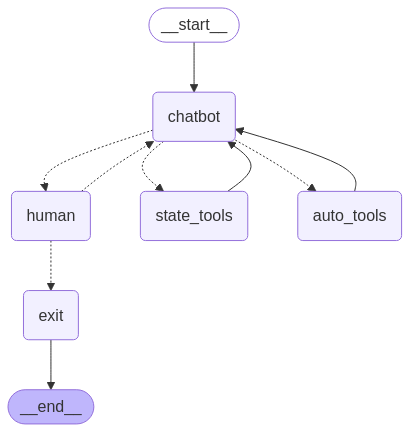

In [18]:
# Tools: the ones that need to manipulate the agent's state
state_manipulation_tools = [search_and_store_results, download_result_and_save_to_context]
# Tools: the ones that do not need to manipulate the agent's state
auto_tools = [remove_pdf_from_memory, query_and_answer_rag]
tool_node = ToolNode(auto_tools)

# Create the llm instance and bind all the tools
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")
llm = llm.bind_tools(state_manipulation_tools + auto_tools)

# Add all nodes to the graph
graph_builder = StateGraph(AgentState)
graph_builder.add_node("chatbot", chatbot_with_tools)
graph_builder.add_node("human", human_node)
graph_builder.add_node("state_tools", tool_interaction_node)
graph_builder.add_node("auto_tools", tool_node)
graph_builder.add_node("exit", exit_node)

# Add edges
# START -> chatbot
graph_builder.add_edge(START, "chatbot")
# chatbot -> human / tools
graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)
# human -> chatbot / exit
graph_builder.add_conditional_edges("human", maybe_exit_human_node)
# tools (1) -> chatbot
graph_builder.add_edge("state_tools", "chatbot")
# tools (2) -> chatbot
graph_builder.add_edge("auto_tools", "chatbot")
# exit -> END
graph_builder.add_edge("exit", END)

# Compile and draw the graph
compiled_graph = graph_builder.compile()
Image(compiled_graph.get_graph().draw_mermaid_png())

## Testing the agent!

Now, after everything, we are finally ready to run a Q&A session with our agent! Uncomment and run the next cell to begin the conversation. Ask the agent about a certain topic, then choose an article and begin your Q&A. Type exit to end the conversation. 

Keep in mind that there are only about 500 papers in the embedded arXiv test collection, all of which are about Computer Vision. Have fun!

In [20]:
# Clean the pdf_embedder state just in case
pdf_embedder.forget()

#config = {"recursion_limit": 100}
#state = compiled_graph.invoke({"messages": []}, config)

Model: Hello! I am a research assistant designed to help you find and understand academic articles from arXiv.org.
        - I can search for papers based on your queries.
        - I can download the PDFs of those papers.
        - I can summarize papers and answer questions about them.
        
        How can I help you today?


User:  lets talk about videos


Model: I found these papers:

1.  Reanimating Images using Neural Representations of Dynamic Stimuli
2.  Multi-identity Human Image Animation with Structural Video Diffusion
3.  Exploring Ordinal Bias in Action Recognition for Instructional Videos
4.  Nepotistically Trained Generative-AI Models Collapse
5.  Computer Vision and Deep Learning for 4D Augmented Reality

Would you like to talk more about one of them?


User:  first one is good


Storing into database: 2406.02659
Model: Okay, I have downloaded "Reanimating Images using Neural Representations of Dynamic Stimuli." Ask me anything about it!


...

Model: The paper "Reanimating Images using Neural Representations of Dynamic Stimuli" presents a method called BrainNRDS that leverages video diffusion models to reanimate images based on brain activity. Here's a breakdown of the process:

1.  **Data Acquisition:** The process begins with fMRI data collected from participants watching video stimuli. This brain activity data is the key to understanding how the brain processes dynamic visual information. The Dynamic Vision Dataset collected by Wen et al. [86] was used.

2.  **Motion Decoding:** BrainNRDS predicts motion labels by processing fMRI and image features. The fMRI data is processed through an MLP (Multilayer Perceptron) and then spatially broadcasted and concatenated over the image features. The concatenated features pass through three residual 1x1 convolutional blocks with dropout, while global features are extracted using AdaptiveAvgPool2d and concatenated back into the spatial features. A final 1x1 convolution classifies eac

User:  Thank you


Model: You're welcome! Is there anything else I can help you with regarding this paper, or would you like to explore a different topic?


User:  exit


Model: Happy to help!


## End note

In this project, we explored how to:
- Embed documents using Google’s text-embedding-004 model.
- Store and manage the embeddings in a vector database with ChromaDB.
- Retrieve the most relevant documents from the database.
- Build an agent using Google’s Gemini Flash model with LangChain.
- Define and call custom tools that enable the agent to search arXiv, download papers, and reason over content dynamically.

The project is meant to serve as a way to learn as well as an introduction to building research-oriented AI agents.

There are many improvements that can be made, such as:
- **Better user interface** - Probably the most obvious one. Since this is only a notebook example, I have not given any effort into user interface when performing Q&A with the agent.
- **Adding more tools** - For example: if none of the documents in database are similar enough, the agent can look up articles directly on the internet.
- **Better memory management** - Right now, the document has to be downloaded and embedded every time the user opens the chat and asks for it. You could implement caching mechanisms to store embeddings and metadata persistently, so that documents only need to be processed once and can be efficiently retrieved on subsequent requests.
- **Contextual understanding** - The agent currently handles documents on a per-query basis, but integrating a system that can track context across multiple user interactions would make the agent capable of maintaining long-term conversations.
- **Expanded model capabilities** - The current setup uses a single model for embeddings and retrieval. You can try out other models or methods for searching through the database such as keyword matching.
- **Using a different PDF loader** - PyPDFLoader currently does not support table extraction. Other ways to extract data from PDFs can be explored and experimented with.
- **Better reasoning** - Currently, the agent has some strugges with finding relevant information in the PDF. To improve reasoning, you can incorporate methods such as multi-step prompting, or experiment with advanced structured thinking.


A big thank you to **Google** and **Kaggle** for hosting the GenAI course. I highly encourage everyone to take some time to go through the released whitepapers when they can.

Notebook made by *Roko Torbarina*.

YouTube video can be found [here](https://www.youtube.com/watch?v=6hh3GUC9dB0).

Blog post can be found [here](https://medium.com/@rokotorbarina9/building-an-ai-agent-for-research-assistance-fb0090bd4899).